<a href="https://colab.research.google.com/github/adamzsl/unsupervised-learning/blob/main/Koralowce_SVM_Full_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import math
import os
import time
import warnings
from types import SimpleNamespace
from itertools import combinations
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, TimeoutError

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import skew, kurtosis
from scipy.ndimage import convolve

from skimage import measure
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops
from skimage.metrics import structural_similarity as ssim
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_ubyte, view_as_windows
from skimage.measure import label, regionprops

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from joblib import Parallel, delayed
from pathlib import Path





# dodać histogram analogiczny wynikły z LBP, schemat analogiczny co harlic i laws filters
# dodać histogram wynikły z innego colorspacu HSV może

# przywrócić resztę filtrów lawa i harlica tak zeby w kntorlowany sposób można było je wyłączać
# LAW_TO_UTILIZE = [1,3,4]
# HARLIC_TO_UTILIZE = [1,2,3]

# spowrotem zintegorwać SSIM
# zrobić macierz pomyłek dla predykcji żeby zlokalziować problematyczne klasy
# zrobić automatyczną normalziacje histogramów - teraz

In [ ]:
PLOT = False
PLOT_EVERY = 1
PRINT = False
ONLY_SAVE = False
SAVED_DATA_EXISTING = False

In [ ]:
Path("learning").mkdir(parents=True, exist_ok=True)
Path("predictions").mkdir(parents=True, exist_ok=True)

Path("learning//contours").mkdir(parents=True, exist_ok=True)
Path("learning//harlic").mkdir(parents=True, exist_ok=True)

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Korale/dataset"

### Train
data_1 = pd.read_parquet(f"{BASE_PATH}/train-00001-of-00009.parquet")
data_2 = pd.read_parquet(f"{BASE_PATH}/train-00002-of-00009.parquet")
data_3 = pd.read_parquet(f"{BASE_PATH}/train-00003-of-00009.parquet")
data_4 = pd.read_parquet(f"{BASE_PATH}/train-00004-of-00009.parquet")
data_6 = pd.read_parquet(f"{BASE_PATH}/train-00006-of-00009.parquet")
data_7 = pd.read_parquet(f"{BASE_PATH}/train-00007-of-00009.parquet")
#data_8 = pd.read_parquet(f"{BASE_PATH}/train-00008-of-00009.parquet")

### Test
test_1 = pd.read_parquet(f"{BASE_PATH}/test-00000-of-00003.parquet")
test_2 = pd.read_parquet(f"{BASE_PATH}/test-00001-of-00003.parquet")
#test_3 = pd.read_parquet(f"{BASE_PATH}/test-00002-of-00003.parquet")

### Validation
val_1 = pd.read_parquet(f"{BASE_PATH}/validation-00000-of-00001.parquet")

# Łączenie
#dataset = pd.concat(
#    [data_1, data_2, data_3, data_4, data_6, data_7, val_1],
#    ignore_index=True
#)

#test_dataset = pd.concat([test_1, test_2], ignore_index=True)

### Do szybszego testowania
dataset = pd.concat([data_1], ignore_index=True)
test_dataset = pd.concat([test_1], ignore_index=True)


Mounted at /content/drive


In [ ]:
def apply_underwater_pipeline(img_rgb):
    if img_rgb.dtype != np.uint8:
        img = np.clip(img_rgb, 0, 255).astype(np.uint8)
    else:
        img = img_rgb.copy()

    img_f = img.astype(np.float32)
    avg = np.mean(img_f, axis=(0,1))
    avg_gray = np.mean(avg)
    avg[avg == 0] = 1.0
    scale = avg_gray / avg
    img_wb = np.clip(img_f * scale, 0, 255).astype(np.uint8)

    lab = cv2.cvtColor(img_wb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    lab2 = cv2.merge([L2, A, B])
    img_clahe = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

    return cv2.bilateralFilter(img_clahe, d=7, sigmaColor=75, sigmaSpace=75)


In [ ]:
################################################## Funkcje z poprzedniej wersji do integracji ##################################################

def get_biggest_patch(sample_array, mask, patch_size=20):
    """Znajduje kwadrat o wymiarze minimum patch_size wewnątrz obszaru wskazanego przez label z datasetu albo SILC """
    largest_region = get_largest_region(mask)
    if largest_region is None:
        return None

    rect = find_rectangle_in_region(largest_region, mask, rect_size=patch_size)
    if rect is None:
        return None

    r, c, s, _ = rect
    return sample_array[r:r+s, c:c+s]


################################################################################################################################################


def find_rectangle_in_region(region, mask, rect_size=20, center_first=True):

    minr, minc, maxr, maxc = region.bbox
    region_mask = mask[minr:maxr, minc:maxc]

    h, w = region_mask.shape
    if h < rect_size or w < rect_size:
        return None

    # --- 1) SZUKANIE W CENTRUM ---
    if center_first:
        center_r = h // 2 - rect_size // 2
        center_c = w // 2 - rect_size // 2

        # dopasowanie, aby nie wychodziło poza obszar
        center_r = max(0, min(center_r, h - rect_size))
        center_c = max(0, min(center_c, w - rect_size))

        window = region_mask[center_r:center_r+rect_size, center_c:center_c+rect_size]

        if window.all():
            return (minr + center_r, minc + center_c, rect_size, rect_size)

        # --- 2) SZUKANIE ITERACYJNE WOKÓŁ CENTRUM (spiralnie) ---
        offsets = list(range(-10, 11, 2))  # promień poszukiwań
        for dr in offsets:
            for dc in offsets:
                rr = center_r + dr
                cc = center_c + dc
                if rr < 0 or cc < 0 or rr + rect_size > h or cc + rect_size > w:
                    continue

                window = region_mask[rr:rr+rect_size, cc:cc+rect_size]
                if window.all():
                    return (minr + rr, minc + cc, rect_size, rect_size)

    # --- 3) OSTATECZNY FALLBACK: zwykłe przeszukiwanie ---
    for r in range(h - rect_size + 1):
        for c in range(w - rect_size + 1):
            window = region_mask[r:r+rect_size, c:c+rect_size]
            if window.all():
                return (minr + r, minc + c, rect_size, rect_size)

    return None

################################################################################################################################################

from skimage.measure import label, regionprops
def get_largest_region(mask, connectivity=2):
    """Na labelach klasa zazwyczaj ma wiele subobszarów - znajduje największy"""
    labeled, _ = label(mask, connectivity=connectivity, return_num=True)
    regions = regionprops(labeled)

    if not regions:
        return None

    return max(regions, key=lambda r: r.area)


################################################################################################################################################

def extract_ssim_features(patch, win_size=None):
    """
    Zwraca cechy SSIM:
    [mean_ssim_vs_blur, std_ssim_vs_blur,
     mean_ssim_vs_rot, std_ssim_vs_rot,
     mean_quadrants_ssim]
    """
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)

    # 1) Blur comparisons
    ssim_vals_blur = []
    for sigma in (1.0, 2.0, 3.0):
        blurred = cv2.GaussianBlur(gray, (0,0), sigma)
        val = ssim(gray, blurred, data_range=max(1, blurred.max()-blurred.min()))
        ssim_vals_blur.append(val)

    # 2) Rotations
    ssim_vals_rot = []
    h, w = gray.shape
    center = (w//2, h//2)
    for angle in (5, -5, 10, -10):
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rot = cv2.warpAffine(gray, M, (w, h), cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        val = ssim(gray, rot, data_range=max(1, rot.max()-rot.min()))
        ssim_vals_rot.append(val)

    # 3) Quadrants MSSSIM-like approximation
    h2, w2 = h//2, w//2
    quads = [
        gray[:h2, :w2],
        gray[:h2, w2:],
        gray[h2:, :w2],
        gray[h2:, w2:]
    ]
    ssim_quads = []
    for q in quads:
        if q.size == 0:
            ssim_quads.append(0.0)
        else:
            val = ssim(q, cv2.GaussianBlur(q, (3,3), 1.0),
                       data_range=max(1, q.max()-q.min()))
            ssim_quads.append(val)

    return np.array([
        np.mean(ssim_vals_blur), np.std(ssim_vals_blur),
        np.mean(ssim_vals_rot), np.std(ssim_vals_rot),
        np.mean(ssim_quads),
    ], dtype=np.float32)



################################################################################################################################################

In [ ]:
def PlotImage(OrginalPicture, segments_slic, title):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(mark_boundaries(OrginalPicture, segments_slic))
    ax.set_title(f'{title}')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [ ]:
def DataLoader(dataset, sample_number, desired_dim):
    """
    Load sample image and label image from dataset for a given sample index.
    """
    row = dataset.iloc[sample_number]
    if desired_dim is not None:
        sample_img = Image.open(io.BytesIO(row['image']['bytes'])).convert("RGB").resize(desired_dim, Image.BILINEAR)
        label_img  = Image.open(io.BytesIO(row['label']['bytes'])).convert("RGB").resize(desired_dim, Image.NEAREST)
    else:
        sample_img = Image.open(io.BytesIO(row['image']['bytes'])).convert("RGB")
        label_img  = Image.open(io.BytesIO(row['label']['bytes'])).convert("RGB")

    return np.array(sample_img).astype(np.uint8), np.array(label_img).astype(np.uint8)


def get_unique_classes(labels_array):

    unique = np.unique(labels_array.reshape(-1, 3), axis=0)
    return [tuple(c.tolist()) for c in unique]

In [ ]:
def ensure_uint8(img):
    if img.dtype != np.uint8:
        return np.clip(img, 0, 255).astype(np.uint8)
    return img

In [ ]:
def _process_single_window(window, levels, win_size):
    """
    9 cech dla okna
    """
    wq = (window.astype(np.float32) * (levels / 256.0)).astype(np.uint8)
    wq[wq >= levels] = levels - 1

    glcm = graycomatrix(
        wq,
        distances=[1],
        angles=[0],
        levels=levels,
        symmetric=True,
        normed=True
    )

    energy        = graycoprops(glcm, 'energy')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    correlation   = graycoprops(glcm, 'correlation')[0, 0]

    # ####### BYŁO ######
    # energy        = graycoprops(glcm, 'energy')[0, 0]
    # contrast      = graycoprops(glcm, 'contrast')[0, 0]
    # dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    # homogeneity   = graycoprops(glcm, 'homogeneity')[0, 0]
    # ASM           = graycoprops(glcm, 'ASM')[0, 0]
    # correlation   = graycoprops(glcm, 'correlation')[0, 0]

    # flat = window.reshape(-1).astype(np.float32)
    # variance_val      = np.var(flat)
    # skewness_val      = skew(flat)
    # kurtosis_val      = kurtosis(flat)
    # ####### BYŁO ######



    return (
        energy, dissimilarity, correlation,
    )


def apply_harlick_stats_to_full_image(FullImage, win_size=10, levels=32, stride=1, n_jobs=-1):
    FullImage = FullImage.astype(np.uint8)
    pad = win_size // 2

    padded = cv2.copyMakeBorder(FullImage, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    gray = cv2.cvtColor(padded, cv2.COLOR_RGB2GRAY).astype(np.uint8)

    windows = view_as_windows(gray, (win_size, win_size), step=stride)
    winH, winW = windows.shape[0], windows.shape[1]

    flat_windows = windows.reshape(-1, win_size, win_size)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_process_single_window)(w, levels, win_size)
        for w in flat_windows
    )

    results = np.array(results).reshape(winH, winW, 3)

    H, W = FullImage.shape[:2]
    results_cropped = results[:H, :W, :]

    return [results_cropped[:, :, i] for i in range(3)]

In [ ]:
#### NOWE - LAWS FILTERS

def laws_kernels():
    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2, 0, 2, 1])
    S5 = np.array([-1, 0, 2, 0, -1])
    R5 = np.array([1, -4, 6, -4, 1])

    kernels = [
        np.outer(L5, L5),
        np.outer(E5, E5),
        np.outer(S5, R5)
    ]


    ###### Było ######

    # kernels = [
    #     np.outer(L5, L5),
    #     np.outer(L5, E5),
    #     np.outer(L5, S5),
    #     np.outer(L5, R5),
    #     np.outer(E5, E5),
    #     np.outer(E5, S5),
    #     np.outer(E5, R5),
    #     np.outer(S5, S5),
    #     np.outer(S5, R5)
    # ]

    ###### Było ######

    return kernels

def calculate_laws_energy(window, kernels):

    energies = []
    for kernel in kernels:
        convolved = convolve(window, kernel)
        energy = np.sum(convolved ** 2)
        energies.append(energy)
    return energies

def _process_single_window_laws(window, kernels):

    window = window.astype(np.float32)
    return calculate_laws_energy(window, kernels)

def apply_laws_texture_energy_to_full_image(FullImage, win_size=10, stride=1, n_jobs=-1):
    FullImage = FullImage.astype(np.uint8)
    pad = win_size // 2

    padded = cv2.copyMakeBorder(
        FullImage, pad, pad, pad, pad, cv2.BORDER_REFLECT
    )
    gray = cv2.cvtColor(padded, cv2.COLOR_RGB2GRAY).astype(np.uint8)

    windows = view_as_windows(gray, (win_size, win_size), step=stride)
    winH, winW = windows.shape[0], windows.shape[1]

    flat_windows = windows.reshape(-1, win_size, win_size)

    kernels = laws_kernels()

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_process_single_window_laws)(w, kernels) for w in flat_windows
    )

    results = np.array(results).reshape(winH, winW, 3)
    results_transposed = np.transpose(results, (2, 0, 1))

    H, W = FullImage.shape[:2]
    results_cropped = results_transposed[:, :H, :W]

    return results_cropped



In [ ]:
def get_all_regions(mask, connectivity=2, min_size=500):
    """Zwraca listę regionprops dla wszystkich fragmentów większych niż min size pikseli."""
    labeled = label(mask, connectivity=connectivity)
    regions = regionprops(labeled)
    org_len = len(regions)
    big_enaugh =  [region for region in regions if region.area > min_size]
    return big_enaugh, org_len

In [ ]:
def color_histogram_for_region(image_array, mask, bins=32, value_range=(0,255)):
    pixels = image_array[mask]
    Rhist, R_Bins = np.histogram(pixels[:,0], bins=bins, range=value_range)
    Ghist, G_Bins = np.histogram(pixels[:,1], bins=bins, range=value_range)
    Bhist, B_Bins = np.histogram(pixels[:,2], bins=bins, range=value_range)
    return np.vstack([Rhist, Ghist, Bhist]), np.vstack([R_Bins, G_Bins, B_Bins])

In [ ]:
def harlic_histogram_for_region(harlic_img, mask, bins=32, i = 1, value_range = [0,1]):

    """ funkcja robi histogram jak dla koloru ale że tu nie jest ustalona max wartość jak 255 dla piskela to koniecza jest normalziacja już po wszystkim"""

    class_pixels = harlic_img[mask]
    try:
        Values, Bins = np.histogram(class_pixels, bins=bins, range = value_range)
    except:

        Values = np.array([0,0,0,0,0,0,0,0,0,0])
        Bins = np.array([0,0,0,0,0,0,0,0,0,0])

    try:
        top =np.percentile(Bins, 95)
        bottom = np.percentile(Bins, 5)
        borders = [top, bottom]
    except:
        borders = [np.nan, np.nan]
    return Values.astype(np.float32), Bins

In [ ]:
harlic_max = [1, 5.26, 1]
harlic_min = [ 0.09, 0, -0.04]
max_law = [3.5762848e+11, 7.5810464e+07, 2.6053260e+07]
min_law = [2.5930235e+09, 1.7176000e+03, 9.7279999e+02]
color_max = [255,255,255]
color_min = [0, 0, 0]

In [ ]:
def ExtractFeaturesFromSegment(sample_array, region_mask,
                               class_color, harlick_images, laws_images, hist_bins=32, idx = 1):
    """
    sample_array: pełny obraz RGB
    region_mask: bool 2D maska regionu (True dla pikseli regionu)
    harlick_images: lista haralickowych obrazów
    """
    mask = region_mask  #

    color_hists, color_borders_list = color_histogram_for_region(sample_array, mask, bins=hist_bins)
    color_hists = color_hists.flatten()

    harlic_hist_list = []
    laws_hist_list = []

    harlic_hist_borders_list = []
    laws_hist_borders_list = []



    for harlic_img, z_min, z_max in zip(harlick_images, harlic_min, harlic_max):
        h, Bins = harlic_histogram_for_region(harlic_img, mask, bins=hist_bins, i = idx, value_range = [z_min, z_max])
        harlic_hist_list.append(h)
        harlic_hist_borders_list.append(Bins)


    for laws_img, z_min, z_max in zip(laws_images, min_law, max_law):
        h, Bins = harlic_histogram_for_region(laws_img, mask, bins=hist_bins, i = idx, value_range = [z_min, z_max])
        laws_hist_list.append(h)
        laws_hist_borders_list.append(Bins)


    harlic_hists = np.concatenate(harlic_hist_list)
    laws_hists = np.concatenate(laws_hist_list)

    features_vector = np.concatenate([color_hists, harlic_hists, laws_hists])

    return features_vector, harlic_hist_borders_list, laws_hist_borders_list, color_borders_list


In [ ]:
def plot_all_contours_and_labels(sample_array,labels_array,classes_list, pic_index):
    H_s, W_s, C_s = sample_array.shape
    H_l, W_l, C_l = labels_array.shape

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(sample_array)
    axes[0].set_title("Original Image with Contours")
    axes[0].axis("off")

    colored_labels = np.zeros((H_l, W_l, 3), dtype=float)
    colors = plt.cm.tab10.colors

    for idx, cl in enumerate(classes_list):
        cl_arr = np.array(cl).reshape(1, 1, 3)
        mask_class = np.all(labels_array == cl_arr, axis=-1)

        class_contours = measure.find_contours(mask_class.astype(float), 0.5)
        for contour in class_contours:
            axes[0].plot(contour[:, 1], contour[:, 0],
                         linewidth=3, color='red')

        regions, _ = get_all_regions(mask_class)

        for reg in regions:
            coords = reg.coords
            if coords.size == 0:
                continue

            valid_mask = (
                (coords[:, 0] >= 0) & (coords[:, 0] < H_l) &
                (coords[:, 1] >= 0) & (coords[:, 1] < W_l)
            )
            coords = coords[valid_mask]

            color_val = colors[idx % len(colors)][:3]
            colored_labels[coords[:, 0], coords[:, 1], :] = color_val

            region_mask = np.zeros_like(mask_class, dtype=float)
            region_mask[coords[:, 0], coords[:, 1]] = 1.0
            region_contours = measure.find_contours(region_mask, 0.5)
            for contour in region_contours:
                axes[0].plot(contour[:, 1], contour[:, 0],
                             linewidth=1, color="black")

    colored_labels_uint8 = np.clip(colored_labels * 255.0, 0, 255).astype(np.uint8)

    axes[1].imshow(colored_labels_uint8)
    axes[1].set_title("Classes Colored")
    axes[1].axis("off")

    patches = [
        mpatches.Patch(color=colors[i % len(colors)], label=f"Class {cl}")
        for i, cl in enumerate(classes_list)
    ]
    axes[1].legend(handles=patches, loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(f"learning//contours//{pic_index}.jpg")
    if ONLY_SAVE == True:
        plt.close()
    else:
        plt.show()

In [ ]:
def plot_haralick_images(harlick_images, pic_index, folder):
    n = len(harlick_images)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    axes = axes.ravel()

    for i, img_arr in enumerate(harlick_images):
        im = axes[i].imshow(img_arr, cmap='viridis')
        fig.colorbar(im, ax=axes[i], shrink=0.8, pad=0.02)
        axes[i].set_title(f'Haralick {i+1}')

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(f"learning//{folder}//{pic_index}.jpg")

    if ONLY_SAVE == True:
        plt.close()
    else:
        plt.show()

In [ ]:
def FullAnalysis(dataset, sample_number, desired_dim=None, global_histograms=None, pic_index = 1):

    row = dataset.iloc[sample_number]

    ### Load
    if desired_dim is not None:
        sample_img = Image.open(io.BytesIO(row['image']['bytes'])).convert("RGB").resize(desired_dim, Image.BILINEAR)
        label_img  = Image.open(io.BytesIO(row['label']['bytes'])).convert("RGB").resize(desired_dim, Image.NEAREST)
    else:
        sample_img = Image.open(io.BytesIO(row['image']['bytes'])).convert("RGB")
        label_img  = Image.open(io.BytesIO(row['label']['bytes'])).convert("RGB")


    sample_array = np.array(sample_img).astype(np.uint8)
    sample_array = apply_underwater_pipeline(sample_array)
    labels_array = np.array(label_img).astype(np.uint8)

    ### Classes
    classes_list = get_unique_classes(labels_array)

    ### Haralick
    harlick_images = apply_harlick_stats_to_full_image(sample_array)
    # print(np.array(harlick_images).shape)
    ### Laws filters
    laws_images = apply_laws_texture_energy_to_full_image((sample_array))
    # print(np.array(laws_images).shape)


    if PLOT & ((pic_index % PLOT_EVERY) == 0):
        plot_haralick_images(harlick_images, pic_index, "harlic")

    if PLOT & ((pic_index % PLOT_EVERY) == 0):
        plot_haralick_images(laws_images, pic_index, "law")

    Features_Array = []
    Classes_Array  = []

    Harlic_Borders_Array = []
    Laws_Borders_Array = []
    colors_border_Array = []

    for idx, cl in enumerate(classes_list):

        mask_class = np.all(labels_array == np.array(cl).reshape(1,1,3), axis=-1)
        regions, org_len = get_all_regions(mask_class)

        if PRINT:
            print(f"Class {cl}: {len(regions)}/{org_len} usable regions")

        for reg in regions:
            coords = reg.coords
            region_mask = np.zeros_like(mask_class, dtype=bool)
            region_mask[coords[:, 0], coords[:, 1]] = True

            features, harlic_hist_borders_list, laws_hist_borders_list, colors_border_list = ExtractFeaturesFromSegment(
                sample_array,
                region_mask,
                cl,
                harlick_images,
                laws_images,
                hist_bins=32,
                idx=idx
            )

            Features_Array.append(features)
            Classes_Array.append(cl)
            Harlic_Borders_Array.append(harlic_hist_borders_list)
            Laws_Borders_Array.append(laws_hist_borders_list)
            colors_border_Array.append(colors_border_list)

    if PLOT & ((sample_number % PLOT_EVERY) == 0):
        plot_all_contours_and_labels(sample_array, labels_array, classes_list, pic_index = pic_index)

    # try:
    #     print(np.array(Features_Array).shape)
    #     print(np.array(Classes_Array).shape)
    #     print(np.array(Borders_Array).shape)
    # except Exception as E:
    #     print("Shape error:", E)

    return Features_Array, Classes_Array, global_histograms, Harlic_Borders_Array, Laws_Borders_Array, colors_border_Array


In [ ]:
from tqdm import tqdm

# =========================
# TRYB PRACY (ZMIENIASZ TU)
# =========================

FAST_MODE = True          # True = testy, False = finalne liczenie
MAX_SAMPLES = 20          # ile obrazów w FAST MODE
DESIRED_DIM_FAST = (256, 128)
DESIRED_DIM_FULL = (512, 256)

# Co liczymy (WYŁĄCZAJ, jeśli nie testujesz)
USE_HARALICK = False
USE_LAWS = False
USE_COLORS = True
USE_LBP = True            # nowy histogram LBP / HSV

# =========================
# PARAMETRY ZALEŻNE OD TRYBU
# =========================

desired_dim = DESIRED_DIM_FAST if FAST_MODE else DESIRED_DIM_FULL
num_samples = min(len(dataset), MAX_SAMPLES) if FAST_MODE else len(dataset)

# =========================
# BUFOR NA WYNIKI
# =========================

AllFeatures = []
AllClasses = []

All_Borders_Harlic = []
All_Borders_Law = []
All_Borders_Colors = []

# =========================
# GŁÓWNA PĘTLA EKSTRAKCJI
# =========================
for sample_number in tqdm(
    range(num_samples),
    desc="Processing train samples (FAST)" if FAST_MODE else "Processing train samples (FULL)"
):
    (
        sample_features,
        sample_classes,
        global_histograms,
        Harlic_Borders_Array,
        Laws_Border_Array,
        Colors_borders_Array
    ) = FullAnalysis(
        dataset,
        sample_number,
        desired_dim=desired_dim,
        pic_index=sample_number,
        global_histograms=[]
    )

    AllFeatures.append(sample_features)
    AllClasses.append(sample_classes)

    All_Borders_Harlic.append(Harlic_Borders_Array)
    All_Borders_Law.append(Laws_Border_Array)
    All_Borders_Colors.append(Colors_borders_Array)


Processing train samples (FAST): 100%|██████████| 20/20 [06:16<00:00, 18.85s/it]


In [ ]:
# jest ok ale dla swojej wygody zminiłem na prostszy interface --- potem do tego wrócimy


# import joblib
# import os
# from tqdm import tqdm
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.impute import SimpleImputer

# features_path = "features_train.joblib"
# classes_path = "classes_train.joblib"
# histograms_path = "global_histograms.joblib"
# scaler_path = "scaler.joblib"
# svm_path = "svm_classifier.joblib"

# if os.path.exists(features_path) and os.path.exists(classes_path) and os.path.exists(histograms_path):
#     print("Wczytywanie zapisanych cech i histogramów...")
#     features_train = joblib.load(features_path)
#     classes_train = joblib.load(classes_path)
#     global_histograms = joblib.load(histograms_path)

# else:
#     print("Generowanie cech od zera...")
#     global_histograms = {}
#     features_train = []
#     classes_train = []

#     for sample_number in tqdm(range(len(dataset)), desc="Processing train samples"):
#         sample_features, sample_classes, global_histograms = FullAnalysis(
#             dataset, sample_number, desired_dim=(1024, 512), global_histograms=global_histograms
#         )
#         features_train.extend(sample_features)
#         classes_train.extend(sample_classes)

#     features_train = np.array(features_train)
#     classes_train = np.array(classes_train)

#     joblib.dump(features_train, features_path)
#     joblib.dump(classes_train, classes_path)
#     joblib.dump(global_histograms, histograms_path)
#     print("Cechy i histogramy zapisane do plików.")

# try:
#     print("Feature vector length (example from train):", len(features_train[0]))
# except Exception as e:
#     print("Nie mogę wypisać długości wektora cech:", e)


# if os.path.exists(scaler_path) and os.path.exists(svm_path):
#     print("Wczytywanie zapisanych scaler i SVM...")
#     scaler = joblib.load(scaler_path)
#     svm_classifier = joblib.load(svm_path)

# else:
#     print("Trening nowych modeli scaler i SVM...")

#     imputer = SimpleImputer(strategy='mean')
#     features_train_imputed = imputer.fit_transform(features_train)

#     scaler = StandardScaler()
#     features_train_scaled = scaler.fit_transform(features_train_imputed)

#     svm_classifier = SVC(kernel='linear', probability=True)
#     svm_classifier.fit(features_train_scaled, classes_train)

#     joblib.dump(imputer, "imputer.joblib")
#     joblib.dump(scaler, scaler_path)
#     joblib.dump(svm_classifier, svm_path)

#     print("Modele zapisane do plików.")


In [ ]:
### wyznaczenie granic binów histogramów trzeba zrobić kod który zrobi to automatycznie



# max_harlic = np.array(All_Borders_Harlic_Flat).max(axis=2)
# min_harlic = np.array(All_Borders_Harlic_Flat).min(axis=2)

# max_law = np.array(All_Borders_Law_Flat).max(axis=2)
# min_law = np.array(All_Borders_Law_Flat).min(axis=2)

# max_colors = np.array(All_Borders_Colors_Flat).max(axis=2)
# min_colors = np.array(All_Borders_Colors_Flat).min(axis=2)

# max_harlic_95 = np.percentile(max_harlic, 95, axis=0)
# min_harlic_5  = np.percentile(min_harlic, 5, axis=0)

# max_law_95    = np.percentile(max_law, 95, axis=0)
# min_law_5     = np.percentile(min_law, 5, axis=0)

# max_colors_95 = np.percentile(max_colors, 95, axis=0)
# min_colors_5  = np.percentile(min_colors, 5, axis=0)



# print(np.round(max_harlic_95, 2))
# print(np.round(min_harlic_5, 2))

# print(np.round(max_law_95, 2))
# print(np.round(min_law_5, 2))

# print(np.round(max_colors_95, 2))
# print(np.round(min_colors_5, 2))




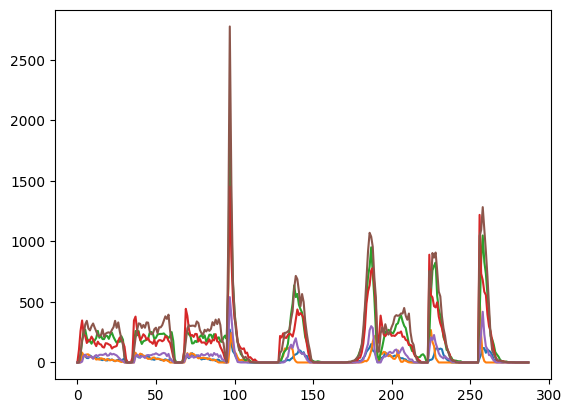

In [ ]:
plt.plot(AllFeatures[0][0])
plt.plot(AllFeatures[2][0])
plt.plot(AllFeatures[3][0])
plt.plot(AllFeatures[5][0])
plt.plot(AllFeatures[4][0])
plt.plot(AllFeatures[6][0])

In [ ]:
#zmienione na potrzeba pracy w colabie

# Katalog tymczasowy na Colabie
TMP_PATH = "/content/tmp_features"
os.makedirs(TMP_PATH, exist_ok=True)

# Ścieżki do plików
FEATURES_FILE = f"{TMP_PATH}/AllFeatures.npy"
CLASSES_FILE = f"{TMP_PATH}/AllClasses.npy"
HARLIC_FILE   = f"{TMP_PATH}/AllBordersHarlic.npy"
LAW_FILE      = f"{TMP_PATH}/AllBordersLaw.npy"
COLORS_FILE   = f"{TMP_PATH}/AllBordersColors.npy"

SAVED_DATA_EXISTING = all([
    os.path.exists(FEATURES_FILE),
    os.path.exists(CLASSES_FILE),
    os.path.exists(HARLIC_FILE),
    os.path.exists(LAW_FILE),
    os.path.exists(COLORS_FILE),
])

if not SAVED_DATA_EXISTING:
    print("Flattening new data")

    AllFeatures_Flat = []
    AllClasses_Flat = []
    All_Borders_Harlic_Flat = []
    All_Borders_Law_Flat = []
    All_Borders_Colors_Flat = []

    for i, (feat_list, class_list, border_list_harlic, border_list_law, border_list_colors) in enumerate(
        zip(AllFeatures, AllClasses, All_Borders_Harlic, All_Borders_Law, All_Borders_Colors)
    ):
        for j, (feat, clas, border_harlic, border_law, border_colors) in enumerate(
            zip(feat_list, class_list, border_list_harlic, border_list_law, border_list_colors)
        ):
            if len(feat) != 288:
                print(f"Skipping index [{i}][{j}] – feature length = {len(feat)} (expected 288)")
                continue

            AllFeatures_Flat.append(feat)
            AllClasses_Flat.append(clas[0])
            All_Borders_Harlic_Flat.append(border_harlic)
            All_Borders_Law_Flat.append(border_law)
            All_Borders_Colors_Flat.append(border_colors)

    # Zapis lokalny (Colab)
    np.save(FEATURES_FILE, AllFeatures_Flat)
    np.save(CLASSES_FILE, AllClasses_Flat)
    np.save(HARLIC_FILE, All_Borders_Harlic_Flat)
    np.save(LAW_FILE, All_Borders_Law_Flat)
    np.save(COLORS_FILE, All_Borders_Colors_Flat)

    print("New data saved to /content/tmp_features")

else:
    print("Loaded cached data from Colab")

    AllFeatures_Flat = np.load(FEATURES_FILE, allow_pickle=True)
    AllClasses_Flat = np.load(CLASSES_FILE, allow_pickle=True)
    All_Borders_Harlic_Flat = np.load(HARLIC_FILE, allow_pickle=True)
    All_Borders_Law_Flat = np.load(LAW_FILE, allow_pickle=True)
    All_Borders_Colors_Flat = np.load(COLORS_FILE, allow_pickle=True)


Flattening new data
New data saved to /content/tmp_features


In [ ]:
print(np.array(AllFeatures_Flat).shape)
print(np.array(AllClasses_Flat).shape)
print(np.array(All_Borders_Harlic_Flat).shape)
print(np.array(All_Borders_Law_Flat).shape)
print(np.array(All_Borders_Colors_Flat).shape)


(1539, 288)
(1539,)
(1539, 3, 33)
(1539, 3, 33)


(216, 288)
(216,)
(216, 3, 33)
(216, 3, 33)
(216, 3, 33)


(1539, 3, 33)

In [ ]:
AllFeatures_Flat = np.array(AllFeatures_Flat)

def normalize_segments(features, n_segments=9, segment_size=32):
    """
    features: shape (n_samples, n_segments*segment_size)
    Normalizes each 32-bin segment across all samples
    """
    n_samples = features.shape[0]
    normalized = np.zeros_like(features, dtype=float)

    for seg in range(n_segments):
        start = seg * segment_size
        end = start + segment_size

        segment_data = features[:, start:end]

        min_val, max_val = segment_data.min(), segment_data.max()

        rescaled = (segment_data - min_val) / (max_val - min_val + 1e-12)

        normalized[:, start:end] = rescaled / (rescaled.sum(axis=1, keepdims=True) + 1e-12)

    return normalized

normalized_data = normalize_segments(AllFeatures_Flat, n_segments=9, segment_size=32)

print(normalized_data.shape)

(216, 288)


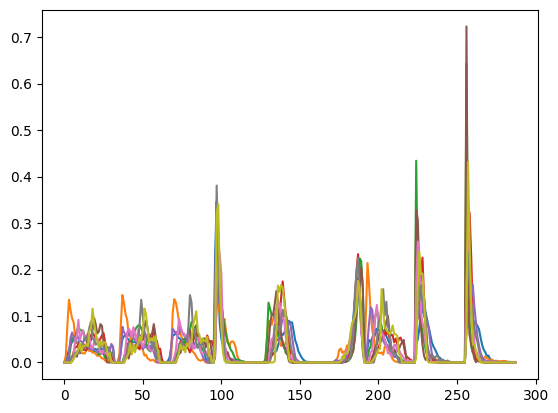

In [ ]:
###### przykłady znormalziowanych wektorów ######

plt.plot(normalized_data[1])
plt.plot(normalized_data[11])
plt.plot(normalized_data[22])
plt.plot(normalized_data[33])
plt.plot(normalized_data[13])
plt.plot(normalized_data[34])
plt.plot(normalized_data[43])
plt.plot(normalized_data[12])
plt.plot(normalized_data[63])
plt.show()

In [ ]:
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(normalized_data)
n_components_chosen = min(pca.n_components_, 200)
pca = PCA(n_components=n_components_chosen)
X_pca = pca.fit_transform(normalized_data)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [ ]:
np.array(AllClasses_Flat).shape

(216,)

In [ ]:
svm = SVC(kernel='rbf', decision_function_shape='ovr')
svm.fit(X_scaled, AllClasses_Flat)

SVC()

### Rózne modele

/tmp/ipython-input-2761534036.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


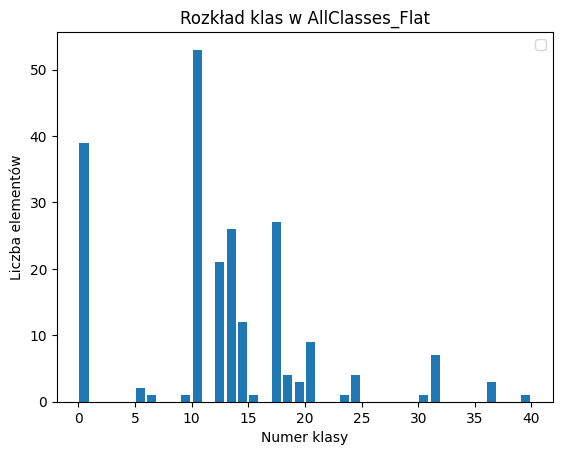

In [ ]:
plt.hist(AllClasses_Flat, bins=range(0, max(AllClasses_Flat) + 2), rwidth=0.8)
plt.title("Rozkład klas w AllClasses_Flat")
plt.xlabel("Numer klasy")
plt.ylabel("Liczba elementów")
plt.legend()
plt.show()

In [ ]:
def train_model_with_timeout(model, X, y, name, timeout=1800, cv=5):
    def train():
        start = time.time()

        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        avg_accuracy = scores.mean()
        print(f"{name} Avg CV Accuracy: {avg_accuracy:.4f} (±{scores.std():.4f})")

        model.fit(X, y)

        filename = f"{name.replace(' ', '_')}_model.joblib"
        joblib.dump(model, filename)
        print(f"{name} saved to {filename}")

        print(f"{name} Training Time: {time.time() - start:.2f}s")
        return avg_accuracy

    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(train)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print(f"{name} training timed out after {timeout} seconds.")
            return None
        except Exception as e:
            print(f"{name} training failed: {e}")
            return None

In [ ]:
### Wsuzstkie klasy

def train_model_with_timeout(model, X, y, name, timeout=1800, cv=5):
    def train():
        start = time.time()

        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        avg_accuracy = scores.mean()
        print(f"{name} Avg CV Accuracy: {avg_accuracy:.4f} (±{scores.std():.4f})")

        model.fit(X, y)

        filename = f"{name.replace(' ', '_')}_model.joblib"
        joblib.dump(model, filename)
        print(f"{name} saved to {filename}")

        print(f"{name} Training Time: {time.time() - start:.2f}s")
        return avg_accuracy

    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(train)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print(f"{name} training timed out after {timeout} seconds.")
            return None
        except Exception as e:
            print(f"{name} training failed: {e}")
            return None


models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, class_weight='balanced', n_jobs=-1, random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
        num_class=len(np.unique(AllClasses_Flat)), random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        num_class=len(np.unique(AllClasses_Flat)), random_state=42, n_jobs=-1
    ),
    "SVC": SVC(
        kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42
    )
}


COMPARE_MODELS = True

if COMPARE_MODELS:
    for name, model in models.items():
        train_model_with_timeout(model, X_scaled, AllClasses_Flat, name)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Random Forest Avg CV Accuracy: 0.4489 (±0.0549)
Random Forest saved to Random_Forest_model.joblib
Random Forest Training Time: 8.34s


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


AdaBoost Avg CV Accuracy: 0.3148 (±0.0345)
AdaBoost saved to AdaBoost_model.joblib
AdaBoost Training Time: 4.99s
XGBoost training failed: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


LightGBM Avg CV Accuracy: 0.4490 (±0.0427)
LightGBM saved to LightGBM_model.joblib
LightGBM Training Time: 30.42s
SVC Avg CV Accuracy: 0.3841 (±0.0363)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


SVC saved to SVC_model.joblib
SVC Training Time: 0.27s


In [ ]:
print("Kształt AllClasses_Flat:", np.shape(AllClasses_Flat))


Kształt AllClasses_Flat: (216,)


In [ ]:
def classify_segments_by_hist(segments_slic, img_array, scaler, svm_classifier):

    img_array = ensure_uint8(img_array)

    sample_array = apply_underwater_pipeline(img_array)


    class_mask = np.zeros_like(segments_slic, dtype=np.uint8)

    harlick_images = apply_harlick_stats_to_full_image(sample_array)
    laws_images = apply_laws_texture_energy_to_full_image(sample_array)

    for seg_id in np.unique(segments_slic):
        mask = segments_slic == seg_id

        features_vector, harlic_hist_borders_list, laws_hist_borders_list, color_borders_list = ExtractFeaturesFromSegment(img_array, mask, class_color=None, harlick_images=harlick_images, laws_images=laws_images, hist_bins = 32, idx = seg_id)

        normalized_f_vecotr = normalize_segments(np.array([features_vector]))

        features = normalized_f_vecotr.reshape(1, -1)

        features_smaller = pca.transform(features)
        features_scaled = scaler.transform(features_smaller)
        pred_class = svm.predict(features_scaled)[0]

        class_mask[mask] = int(pred_class)

    return class_mask


In [ ]:
def CorrMatrixBetweenClasses(SegmentationFilter, OrginalPicture):
    """
        Podobieństwo między histogrammi róznych segmentów
        Dodana normalizacja historgamów

    """
    num_classes = np.max(SegmentationFilter) + 1

    Red_Dict = {}
    Green_Dict = {}
    Blue_Dict = {}

    for class_id in range(1, num_classes):
        mask = SegmentationFilter == class_id
        segment_pixels = OrginalPicture[mask]

        bins = 256
        bin_edges = np.linspace(0, 256, bins + 1)

        red_hist = np.histogram(segment_pixels[:, 0], bins=bin_edges)[0]
        green_hist = np.histogram(segment_pixels[:, 1], bins=bin_edges)[0]
        blue_hist = np.histogram(segment_pixels[:, 2], bins=bin_edges)[0]


        Red_Dict[class_id] = red_hist / red_hist.sum()
        Green_Dict[class_id] = green_hist / green_hist.sum()
        Blue_Dict[class_id] = blue_hist / blue_hist.sum()

    Corr_R = np.corrcoef(pd.DataFrame(Red_Dict).T)
    Corr_G = np.corrcoef(pd.DataFrame(Green_Dict).T)
    Corr_B = np.corrcoef(pd.DataFrame(Blue_Dict).T)

    Corr_Mean = (Corr_B + Corr_G + Corr_R) /3
    return Corr_Mean

def FindUniquePairs(segments_slic):
    """Creates pairs of SLIC segments in proximity"""
    arr_of_sets = []
    for i in range(1, len(segments_slic), 2):
        for j in range(1, len(segments_slic[i]), 2):
            try:
                current = segments_slic[i, j]
                next_right = segments_slic[i, j+1]
                next_left = segments_slic[i, j-1]
                next_up = segments_slic[i-1, j]
                next_down = segments_slic[i+1, j]
                val_set = {next_right, next_left, next_up, next_down, current}
                if len(val_set) > 1:
                    arr_of_sets.append(val_set)
            except:
                continue

    unique_pairs = set()

    for val_set in arr_of_sets:
        for pair in combinations(val_set, 2):
            unique_pairs.add(tuple(sorted(pair)))
    unique_pairs = list(unique_pairs)
    return unique_pairs

def FindCorrelatedPairs(unique_pairs, Corr_Mean, treshold):
    """Finds segments that can be merged due to similarity"""
    Similar_Pairs = []
    for (a,b) in unique_pairs:
        pair_corr = Corr_Mean[a-1, b-1]
        if pair_corr > treshold:
            Similar_Pairs.append((a,b))
        else:
            continue
    return Similar_Pairs

def MergeAreas(Similar_Pairs, segments_slic):
    for (a,b) in Similar_Pairs:
        segments_slic[segments_slic == a] = b
    return segments_slic

def Reindex(mergedSlic):
    unique_classes = np.unique(mergedSlic)
    mapping = {old: new for new, old in enumerate(unique_classes, start=1)}
    reindexed = np.vectorize(mapping.get)(mergedSlic)
    return reindexed, unique_classes


def merge_superpixels(img_array, n_segments=50, compactness=10, sigma=1, merge_threshold=0.8, plot=True, verbose=True):
    """Dzieli wedle algorytmu SLIC, potem łączy podobne superpiksele - uwaga!: łączy je tylko po kolorze a nie kolorze i cechach fakturowych"""
    segments_slic = slic(img_array, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=1)

    if plot:
        PlotImage(img_array, segments_slic, "SLIC")

    last_num_areas = None
    current_num_areas = len(np.unique(segments_slic))

    while True:
        Corr_Mean = CorrMatrixBetweenClasses(segments_slic, img_array)
        unique_pairs = FindUniquePairs(segments_slic)
        Similar_Pairs = FindCorrelatedPairs(unique_pairs, Corr_Mean, merge_threshold)
        mergedSlic = MergeAreas(Similar_Pairs, segments_slic)
        segments_slic, unique_classes = Reindex(mergedSlic)
        current_num_areas = len(unique_classes)

        if verbose:
            print(f"Number of areas = {current_num_areas}")

        if last_num_areas is not None and last_num_areas == current_num_areas:
            break
        last_num_areas = current_num_areas

    if plot:
        PlotImage(img_array, segments_slic, 'SLIC MERGED')

    return segments_slic


In [ ]:
def class_to_rgb(class_image, color_map, default_color=[0, 0, 0]):
    """
    Zamienia tablicę klas na RGB według color_map.
    Jeśli klasa nie ma koloru, używa default_color.
    """
    class_image = np.array(class_image, copy=True, dtype=np.int32)
    rgb_image = np.zeros(class_image.shape + (3,), dtype=np.uint8)

    for cls, color in color_map.items():
        mask = (class_image == cls)
        rgb_image[mask, :] = color

    mask_unknown = ~np.isin(class_image, list(color_map.keys()))
    rgb_image[mask_unknown, :] = default_color

    return rgb_image


def ShowQuad(original, label, predicted, color_map, pic_index):
    label_rgb = class_to_rgb(label, color_map)
    predicted_rgb = class_to_rgb(predicted, color_map)

    identical_elements = (label == predicted)
    bw_image = np.zeros(label.shape, dtype=np.uint8)
    bw_image.setflags(write=1)
    bw_image[identical_elements] = 255

    num_identical = np.sum(identical_elements) / (label.shape[0] * label.shape[1])
    print(f"Percentage of identical pixels: {num_identical*100:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(20, 11))

    axes[0][0].imshow(original)
    axes[0][0].set_title('Original image')
    axes[0][0].axis('off')

    axes[0][1].imshow(label_rgb)
    axes[0][1].set_title('Label')
    axes[0][1].axis('off')

    axes[1][0].imshow(predicted_rgb)
    axes[1][0].set_title('Predicted mask')
    axes[1][0].axis('off')

    axes[1][1].imshow(bw_image, cmap='gray')
    axes[1][1].set_title('Same class map')
    axes[1][1].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.15)

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    legend_patches = [
        mpatches.Patch(color=np.array(color)/255.0, label=str(cls))
        for cls, color in color_map.items()
    ]

    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=min(len(legend_patches), 6),
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.2)
    )

    plt.savefig(f"predictions//{pic_index}.jpg", bbox_inches='tight')
    if ONLY_SAVE:
        plt.close()
    else:
        plt.show()


In [ ]:
color_map = {
    0:  [230, 159,   0],
    1:  [ 86, 180, 233],
    2:  [  0, 158, 115],
    3:  [213,  94,   0],
    4:  [204, 121, 167],
    5:  [240, 228,  66],
    6:  [  0, 114, 178],
    7:  [102, 194, 165],
    8:  [252, 141,  98],
    9:  [141, 160, 203],
    10: [231, 138, 195],
    11: [166, 216,  84],
    12: [240, 228,  66],
    13: [204, 121, 167],
    14: [  0, 114, 178],
    15: [141, 211, 199],
    16: [255, 255, 179],
    17: [190, 186, 218],
    18: [251, 128, 114],
    19: [128, 177, 211],
    20: [253, 180,  98],
    21: [179, 222, 105],
    22: [252, 205, 229],
    23: [217, 217, 217],
    24: [188, 128, 189],
    25: [204, 235, 197],
    26: [255, 237, 111],
    27: [ 97, 156, 255],
    28: [255, 125, 125],
    29: [125, 255, 125],
    30: [255, 190, 125],
    31: [153, 153, 153],
    32: [ 65,  68, 135],
    33: [106,  81, 163],
}

In [ ]:
resize_dim = (256, 128)
MAX_TEST_IMAGES = 10

accuracies = []

for idx, row in test_dataset.head(MAX_TEST_IMAGES).iterrows():
    img_orig = Image.open(io.BytesIO(row['image']['bytes'])).convert('RGB').resize(resize_dim, Image.BILINEAR)
    lbl_orig = Image.open(io.BytesIO(row['label']['bytes'])).convert('RGB').resize(resize_dim, Image.NEAREST)

    OrginalPicture = np.array(img_orig, dtype=np.uint8)
    LabelPicture = np.array(lbl_orig, dtype=np.uint8)[:, :, 0]

    # FAST MODE
    processed_for_hist = OrginalPicture

    segments_slic = merge_superpixels(
        OrginalPicture,
        plot=False,
        verbose=False
    )

    class_mask = classify_segments_by_hist(
        segments_slic,
        processed_for_hist,
        scaler,
        svm
    )

    identical = (class_mask == LabelPicture)
    acc = identical.mean()
    accuracies.append(acc)

    print(f"{idx}: {acc:.3f}")

print("Average accuracy:", np.mean(accuracies))


0: 0.011
1: 0.021
2: 0.002
3: 0.032
4: 0.046
5: 0.003
6: 0.009
7: 0.000
8: 0.008
9: 0.001
Average accuracy: 0.01322021484375


In [ ]:
X = np.vstack(AllFeatures[0])

print("LBP+HSV variance (last 50 dims):")
print(np.var(X[:, -50:], axis=0))


LBP+HSV variance (last 50 dims):
[2.27097959e+03 1.49767347e+03 3.89265306e+02 4.36408163e+02
 1.41551020e+02 1.17673469e+02 3.96734694e+01 1.76326531e+01
 0.00000000e+00 4.40816327e+00 4.89795918e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.48590678e+06 4.95982531e+05
 2.29615673e+05 1.54515347e+05 1.08120531e+05 9.32049796e+04
 8.97148571e+04 7.84375510e+04 6.49346939e+04 3.67456327e+04
 1.81626939e+04 9.81053061e+03 6.30653061e+03 2.39053061e+03
 3.01453061e+03 7.88775510e+02 3.07265306e+02 1.59836735e+02
 1.40285714e+02 4.33877551e+01 5.95918367e+00 9.67346939e+00
 7.67346939e+00 1.83673469e+00 4.40816327e+00 7.83673469e+00
 3.14285714e+00 1.76326531e+01 7.67346939e+00 5.30612245e-01
 4.89795918e-01 1.22448980e-01]
